In [1]:
import tenpy
# from tenpy.models.model import CouplingMPOModel
# from tenpy.networks.site import SpinHalfFermionSite
# from tenpy.networks.mps import MPS
# from tenpy.algorithms import dmrg as tenpy_dmrg
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [2]:
REQ_DATA = 't_1.00_U_0.10_Vpp_0.800/v2/'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if "chimax_100" in f]
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : metadata['mean_Sz'], 
        'mean_fill' : metadata['mean_fill'],
        'model_params' : model_params,
        'converged' : metadata['converged']
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df.head()

,psi,dV,mean_Sz,mean_fill,model_params,converged
21,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.95,2.699023e-13,0.471107,"{'L': 2, 'U': 0.1, 'Vpm': 3.75, 'Vpp': 0.8, 'b...",True
23,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.96,5.464823e-13,0.470427,"{'L': 2, 'U': 0.1, 'Vpm': 3.76, 'Vpp': 0.8, 'b...",True
13,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.97,-1.954802e-13,0.469759,"{'L': 2, 'U': 0.1, 'Vpm': 3.7699999999999996, ...",True
12,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.98,2.031404e-13,0.469075,"{'L': 2, 'U': 0.1, 'Vpm': 3.7799999999999994, ...",True
4,"MPS, L=2, bc='infinite'.\nchi: [100, 100]\nsit...",2.99,-1.047686e-12,0.468418,"{'L': 2, 'U': 0.1, 'Vpm': 3.789999999999999, '...",True


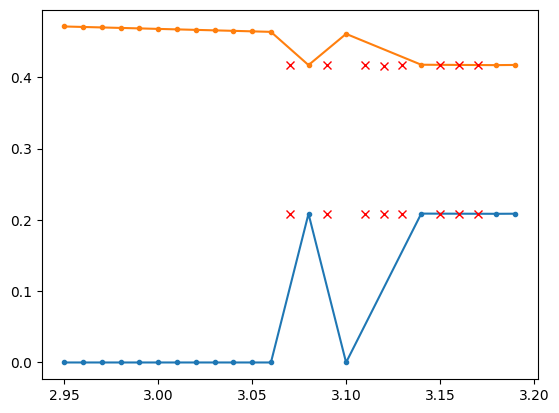

In [6]:
fig, ax = plt.subplots(1)
mask = df['converged']
ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_Sz']), ls='-', marker='.', c='C0')
ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_Sz']), ls='', marker='x', c='r')
ax.plot(df.loc[mask, 'dV'], np.abs(df.loc[mask, 'mean_fill']), ls='-', marker='.', c='C1')
ax.plot(df.loc[~mask, 'dV'], np.abs(df.loc[~mask, 'mean_fill']), ls='', marker='x', c='r')